# pandas vs Polars: DataFrame Library Benchmark

**Docker image**: `ml4t`

**Purpose**: Compare pandas and Polars for financial data operations typical in
ML for trading pipelines. Every number on this page depends on the two library
versions that produced it, so the setup cell prints both, along with whether the
newer pandas performance features are switched on in the environment that ran.
Nothing here asserts what those versions are: the printed values are the record.

**Learning Objectives**:
- Understand performance characteristics of each library for different operations
- Know when to use pandas vs Polars based on operation type and data scale
- Recognize what Copy-on-Write and PyArrow-backed strings change, and read off
  whether the running pandas has them enabled
- Measure memory efficiency for large financial datasets

**Book Reference**: Chapter 2, Section 2.4 (Storing Data) — engine choice
trade-offs alongside file and database benchmarks.

**Prerequisites**: Familiarity with pandas/Polars basics; existing storage benchmarks.

## Key Categories Tested

| Category | Operations | Financial Use Case |
|----------|-----------|-------------------|
| A: Rolling | SMA, EMA, rolling std, Sharpe | Time-series features |
| B: GroupBy | OHLCV resampling, cross-sectional stats | Bar construction |
| C: Window | Z-scores, percentile ranks, lags | Normalized features |
| D: Filtering | Multi-condition predicates | Options chain filtering |
| E: Joins | ASOF (trade-quote), anti-joins | Tick data matching |
| F: Lazy/Streaming | Parquet scan, predicate pushdown | Large file processing |
| G: Memory | Peak usage, allocation patterns | Resource constraints |
| H: Strings | Contains, extract, replace | Ticker manipulation |

## Reading the numbers

A benchmark is only a comparison if both sides compute the same thing. Every pair
below returns the quantity it computed, and the runner reduces both to a row count
and a checksum over their values and refuses the pair if the two disagree. Two
implementations that had drifted apart would otherwise sit side by side on the
chart with no sign that they were answering different questions; two of the pairs
here had.

The scale is the `BENCHMARK_SCALE` parameter below. Change it there, or inject it
with Papermill as CI does. The ordering of the results depends on it, which is why
the summary prints the scale beside every number.

## Setup and Version Detection

In [1]:
"""Pandas vs Polars Benchmark — systematic performance comparison across financial data operations."""

import gc
import math
import os

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from IPython.display import display
from plotly.subplots import make_subplots

### Declared parameters

`BENCHMARK_SCALE` sets the panel size, and `utils.storage_benchmarks` reads it from
the environment when it is imported, so it has to be written there before the import
below rather than passed to a function afterwards.

The window lengths and horizons are the shape of the feature computation being
timed. They are declared here because both libraries have to use the same ones for
the comparison to mean anything, and because a reader changing one should not have
to find it in six places.

In [2]:
BENCHMARK_SCALE = "L"
SEED = 42

SMA_WINDOW = 20  # A1: simple moving average
VOL_WINDOW = 20  # A2: rolling standard deviation
SHARPE_WINDOW = 63  # A4: one quarter of sessions
EWM_SPAN = 20  # A5: exponential moving average
TRADING_DAYS = 252  # A4: annualization factor
HORIZONS = [1, 5, 21, 63, 126, 252]  # A3: return lookbacks
LAGS = [1, 5, 21]  # C3: autoregressive lags
TOP_OPERATIONS_CHARTED = 15  # how many operations the per-operation panel shows

In [3]:
os.environ["BENCHMARK_SCALE"] = BENCHMARK_SCALE

from utils.paths import display_path  # noqa: E402
from utils.reproducibility import set_global_seeds  # noqa: E402
from utils.storage_benchmarks import (  # noqa: E402
    ACTIVE_SCALE,
    BENCHMARK_DIR,
    N_ROWS_PER_SYMBOL,
    N_SYMBOLS,
    RESULTS_DIR,
    TIMING_RUNS,
    estimate_memory_mb,
    generate_ohlcv_data,
    generate_tick_data,
    get_scale_config,
    time_operation,
)
from utils.style import COLORS, show_plotly_with_alt  # noqa: E402

set_global_seeds(SEED)

### Version and Feature Detection

Three pandas changes move these timings, and the cell below reads off whether the
*installed* pandas has each of them rather than asserting a version:

- **Copy-on-Write**: internal views with copy-on-modify semantics.
- **PyArrow-backed strings**: a different string dtype, with different memory use
  and different string-operation costs.
- **The `pd.col()` expression API**: column references in assign and groupby.

All three arrived as defaults in the pandas 3 series, so on an older pandas the cell
below will report them off. Whatever it reports is what produced the numbers on this
page, and it is written into the saved summary alongside them.

In [4]:
PANDAS_VERSION = pd.__version__
POLARS_VERSION = pl.__version__

print("=" * 70)
print("DATAFRAME LIBRARY BENCHMARK")
print("=" * 70)
print(f"\npandas version: {PANDAS_VERSION}")
print(f"Polars version: {POLARS_VERSION}")

try:
    COW_ENABLED = bool(pd.options.mode.copy_on_write)
except AttributeError:
    COW_ENABLED = False

try:
    PYARROW_STRINGS = "pyarrow" in str(pd.Series(["test"]).dtype)
except Exception:
    PYARROW_STRINGS = False

print("\npandas performance features, as installed:")
print(f"  Copy-on-Write: {'enabled' if COW_ENABLED else 'disabled'}")
print(f"  PyArrow strings: {'yes' if PYARROW_STRINGS else 'no'}")

POLARS_STREAMING = False
try:
    pl.Config.set_engine_affinity(engine="streaming")
    POLARS_STREAMING = True
except Exception:
    POLARS_STREAMING = False
print(f"\nPolars streaming engine: {'enabled' if POLARS_STREAMING else 'not available'}")

DATAFRAME LIBRARY BENCHMARK

pandas version: 2.3.3
Polars version: 1.41.1

pandas performance features, as installed:
  Copy-on-Write: disabled
  PyArrow strings: no

Polars streaming engine: enabled


## Data Generation

We use the same synthetic OHLCV and tick data generators as the storage benchmarks
to ensure comparable results across all benchmarks.

In [5]:
scale_cfg = get_scale_config(ACTIVE_SCALE)
print(f"\nScale: {ACTIVE_SCALE} ({scale_cfg['target_memory']} target)")
print(f"OHLCV: {N_SYMBOLS} symbols × {N_ROWS_PER_SYMBOL:,} rows/symbol")

print("\n=== Generating synthetic data ===\n")

# Generate OHLCV data (Polars native)
ohlcv_pl = generate_ohlcv_data(n_symbols=N_SYMBOLS, n_rows=N_ROWS_PER_SYMBOL)
total_rows = len(ohlcv_pl)
print(f"OHLCV: {total_rows:,} rows ({estimate_memory_mb(ohlcv_pl):.1f} MB)")

# Convert to pandas (triggers CoW in pandas 3.0)
ohlcv_pd = ohlcv_pl.to_pandas()
print(f"pandas memory: {ohlcv_pd.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Generate tick data for join benchmarks
trades_pl, quotes_pl = generate_tick_data(
    n_symbols=min(N_SYMBOLS, 50),  # Limit symbols for tick data
    seed=42,
)
n_trades = len(trades_pl)
n_quotes = len(quotes_pl)
print(f"Trades: {n_trades:,} rows")
print(f"Quotes: {n_quotes:,} rows")

# Convert tick data to pandas
trades_pd = trades_pl.to_pandas()
quotes_pd = quotes_pl.to_pandas()

# Store results
results = []


Scale: L (100MB target)
OHLCV: 100 symbols × 10,000 rows/symbol

=== Generating synthetic data ===

OHLCV: 1,000,000 rows (63.9 MB)


pandas memory: 116.0 MB


Trades: 500,000 rows
Quotes: 2,500,000 rows


## Comparing two results, and forcing them to exist

The old helpers here forced materialization separately for each library, and they
did not force the same thing: the pandas one summed every numeric column and then
ran `.astype(str).str.len()` over two string columns, while the Polars one summed at
most five numeric columns and touched no strings. That difference is not part of any
operation being timed, and it was charged to pandas in every category.

One reduction now serves both purposes, and it runs outside the timed region so it
is charged to neither. `result_witness` walks a pandas or Polars result and returns
its row count, the sum of the absolute values of every number in it, the signed sum
of those numbers, and a character count over every string. Two implementations of
the same operation have to agree on all four.

Sums ignore row order, which is what we want: pandas and Polars return grouped
results in different orders and that is not a difference in the answer. The absolute
sum is there because the signed one is not always usable. A column of cross-sectional
z-scores sums to zero by construction, so the two libraries land on opposite sides of
zero at the fifteenth decimal and no relative comparison of that number means
anything. The absolute sum stays large and discriminating exactly where the signed
one goes to zero, and the signed one still catches a flipped sign, which the
absolute one cannot see. Each covers the other's blind spot.

In [6]:
def result_witness(result) -> tuple[int, float, float, int]:
    """Reduce a result to (rows, absolute sum, signed sum, string character count).

    Accepts a pandas or Polars Series or DataFrame. Nulls are skipped rather than
    propagated, because both libraries produce them at the head of every window and
    a NaN checksum would compare equal to nothing, including itself.
    """
    if isinstance(result, pl.LazyFrame):
        result = result.collect()
    if isinstance(result, pd.Series):
        result = result.to_frame()
    if isinstance(result, pl.Series):
        result = result.to_frame()

    absolute = 0.0
    signed = 0.0
    characters = 0
    if isinstance(result, pd.DataFrame):
        rows = len(result)
        for column in result.columns:
            values = result[column]
            if pd.api.types.is_numeric_dtype(values) and not pd.api.types.is_bool_dtype(values):
                numbers = values.to_numpy(dtype=float, na_value=np.nan)
                absolute += float(np.nansum(np.abs(numbers)))
                signed += float(np.nansum(numbers))
            elif pd.api.types.is_string_dtype(values) or values.dtype == object:
                characters += int(values.dropna().astype(str).str.len().sum())
    elif isinstance(result, pl.DataFrame):
        rows = result.height
        for column in result.columns:
            values = result[column]
            if values.dtype.is_numeric():
                numbers = values.drop_nulls().cast(pl.Float64)
                absolute += float(numbers.abs().sum() or 0.0)
                signed += float(numbers.sum() or 0.0)
            elif values.dtype == pl.String:
                characters += int(values.drop_nulls().str.len_chars().sum() or 0)
    else:
        raise TypeError(f"cannot take a witness of {type(result).__name__}")

    return rows, absolute, signed, characters

### Benchmark Runner

Times an operation on both libraries, checks that the two agree, and records the
pair. A disagreement raises: a chart of two implementations that compute different
quantities is worse than no chart, because it looks exactly like a chart of two
implementations that agree.

In [7]:
WITNESS_RELATIVE_TOLERANCE = 1e-9


def benchmark_operation(
    name: str,
    category: str,
    pandas_func,
    polars_func,
    n_runs: int = TIMING_RUNS,
) -> dict:
    """Time an operation on both libraries, after checking they compute the same thing."""
    gc.collect()
    pd_time, pd_result = time_operation(pandas_func, n_runs=n_runs)

    gc.collect()
    pl_time, pl_result = time_operation(polars_func, n_runs=n_runs)

    pd_witness = result_witness(pd_result)
    pl_witness = result_witness(pl_result)
    pd_rows, pd_absolute, pd_signed, pd_characters = pd_witness
    pl_rows, pl_absolute, pl_signed, pl_characters = pl_witness
    # The signed sums are compared on a scale set by the absolute sum, which is what
    # bounds the rounding error two different summation orders can accumulate.
    signed_tolerance = WITNESS_RELATIVE_TOLERANCE * max(pd_absolute, pl_absolute, 1.0)
    agrees = (
        pd_rows == pl_rows
        and pd_characters == pl_characters
        and math.isclose(pd_absolute, pl_absolute, rel_tol=WITNESS_RELATIVE_TOLERANCE, abs_tol=0.0)
        and abs(pd_signed - pl_signed) <= signed_tolerance
    )
    if not agrees:
        raise AssertionError(
            f"{name}: the two implementations do not compute the same result. "
            f"pandas (rows, |sum|, sum, characters)={pd_witness}, polars={pl_witness}"
        )

    speedup = pd_time / pl_time if pl_time > 0 else float("inf")
    print(
        f"  {name}: pandas={pd_time:.4f}s, polars={pl_time:.4f}s, "
        f"speedup={speedup:.1f}x, {pd_rows:,} rows agree"
    )
    return {
        "category": category,
        "operation": name,
        "pandas_time": pd_time,
        "polars_time": pl_time,
        "speedup": speedup,
    }

## Category A: Rolling Calculations

Rolling window operations are fundamental to time-series feature engineering.
We test single-window, multi-horizon, and compound calculations (Sharpe ratio).

In [8]:
print("\n" + "=" * 70)
print("CATEGORY A: ROLLING CALCULATIONS")
print("=" * 70)

rolling_results = []


CATEGORY A: ROLLING CALCULATIONS


### A1: Simple Rolling Mean

A moving average over `SMA_WINDOW` bars per symbol, the foundation of many trading
signals. Both sides return the computed column and nothing else, so the runner is
comparing the same quantity rather than two frames that happen to share a row count.

In [9]:
def pd_rolling_mean():
    return ohlcv_pd.groupby("symbol")["close"].rolling(SMA_WINDOW).mean().reset_index(drop=True)

In [10]:
def pl_rolling_mean():
    """Compute the rolling mean of close per symbol using a Polars window expression."""
    return ohlcv_pl.select(pl.col("close").rolling_mean(SMA_WINDOW).over("symbol").alias("sma"))


r = benchmark_operation("rolling_mean_20", "A_rolling", pd_rolling_mean, pl_rolling_mean)
rolling_results.append(r)

  rolling_mean_20: pandas=0.0702s, polars=0.0208s, speedup=3.4x, 1,000,000 rows agree


### A2: Rolling Standard Deviation (Volatility)

Volatility over `VOL_WINDOW` bars per symbol, for risk management and for
normalizing signals.

In [11]:
def pd_rolling_std():
    return ohlcv_pd.groupby("symbol")["close"].rolling(VOL_WINDOW).std().reset_index(drop=True)

In [12]:
def pl_rolling_std():
    """Compute the rolling standard deviation of close per symbol for volatility."""
    return ohlcv_pl.select(pl.col("close").rolling_std(VOL_WINDOW).over("symbol").alias("vol"))


r = benchmark_operation("rolling_std_20", "A_rolling", pd_rolling_std, pl_rolling_std)
rolling_results.append(r)

  rolling_std_20: pandas=0.0805s, polars=0.0248s, speedup=3.2x, 1,000,000 rows agree


### A3: Multi-Horizon Returns

Feature engineering wants several lookbacks at once, `HORIZONS` of them here. This
is where a single-pass expression engine can separate from a Python loop, so the
loop on the pandas side is deliberate rather than an oversight.

In [13]:
def pd_multi_horizon():
    # One groupby per horizon, which is the pandas idiom and part of what is being
    # compared: Polars expresses all six in a single pass below.
    return pd.DataFrame(
        {f"ret_{h}": ohlcv_pd.groupby("symbol")["close"].pct_change(h) for h in HORIZONS}
    )

In [14]:
def pl_multi_horizon():
    """Compute returns at every horizon in one pass of Polars expressions."""
    return ohlcv_pl.select(
        [pl.col("close").pct_change(h).over("symbol").alias(f"ret_{h}") for h in HORIZONS]
    )


r = benchmark_operation("multi_horizon_returns", "A_rolling", pd_multi_horizon, pl_multi_horizon)
rolling_results.append(r)

  multi_horizon_returns: pandas=0.2553s, polars=0.0464s, speedup=5.5x, 1,000,000 rows agree


### A4: Rolling Sharpe Ratio

A compound calculation: a rolling mean divided by a rolling standard deviation,
annualized. It tests chained window operations, and it is where the two sides had
drifted apart. The pandas side took `pct_change` per symbol and then rolled the
resulting flat Series, so its window ran across the boundary between one symbol and
the next and averaged the two together; Polars had `.over("symbol")` on both windows
and did not. The result was a chart comparing a per-symbol Sharpe against a Sharpe
that mixed symbols, and nothing in the notebook could have told you.

In [15]:
def pd_rolling_sharpe():
    returns = ohlcv_pd.groupby("symbol")["close"].pct_change()
    # Grouped, not a plain rolling window over the frame. `returns` is a flat Series
    # aligned to the panel, so `returns.rolling(...)` walks straight across the
    # boundary from one symbol into the next and averages two symbols together.
    grouped = returns.groupby(ohlcv_pd["symbol"])
    sharpe = (
        grouped.rolling(SHARPE_WINDOW).mean() / grouped.rolling(SHARPE_WINDOW).std()
    ) * np.sqrt(TRADING_DAYS)
    return sharpe.reset_index(drop=True).rename("sharpe")

In [16]:
def pl_rolling_sharpe():
    """Compute the rolling Sharpe ratio per symbol with chained Polars windows."""
    return ohlcv_pl.with_columns(
        pl.col("close").pct_change().over("symbol").alias("returns")
    ).select(
        (
            pl.col("returns").rolling_mean(SHARPE_WINDOW).over("symbol")
            / pl.col("returns").rolling_std(SHARPE_WINDOW).over("symbol")
        )
        .mul(np.sqrt(TRADING_DAYS))
        .alias("sharpe")
    )


r = benchmark_operation("rolling_sharpe_63", "A_rolling", pd_rolling_sharpe, pl_rolling_sharpe)
rolling_results.append(r)

  rolling_sharpe_63: pandas=0.1975s, polars=0.0535s, speedup=3.7x, 1,000,000 rows agree


### A5: Exponential Moving Average

An exponentially weighted mean over `EWM_SPAN`, the smoothing most trend-following
signals are built on.

In [17]:
def pd_ewm():
    return (
        ohlcv_pd.groupby("symbol")["close"]
        .ewm(span=EWM_SPAN, adjust=False)
        .mean()
        .reset_index(drop=True)
    )

In [18]:
def pl_ewm():
    """Compute the exponential moving average of close per symbol with ewm_mean."""
    return ohlcv_pl.select(
        pl.col("close").ewm_mean(span=EWM_SPAN, adjust=False).over("symbol").alias("ema")
    )


r = benchmark_operation("ewm_span_20", "A_rolling", pd_ewm, pl_ewm)
rolling_results.append(r)

results.extend(rolling_results)

  ewm_span_20: pandas=0.0708s, polars=0.0207s, speedup=3.4x, 1,000,000 rows agree


## Category B: GroupBy Aggregations

GroupBy operations are essential for cross-sectional analysis and resampling.

In [19]:
print("\n" + "=" * 70)
print("CATEGORY B: GROUPBY AGGREGATIONS")
print("=" * 70)

groupby_results = []


CATEGORY B: GROUPBY AGGREGATIONS


### B1: OHLCV Resampling (1-min to daily)

Aggregate minute bars to daily bars - common in bar construction pipelines.

In [20]:
def pd_resample():
    return (
        ohlcv_pd.groupby([ohlcv_pd["timestamp"].dt.date, "symbol"])
        .agg(
            {
                "open": "first",
                "high": "max",
                "low": "min",
                "close": "last",
                "volume": "sum",
            }
        )
        .reset_index(drop=True)
    )

In [21]:
def pl_resample():
    """Resample to daily bars with Polars group_by and first/max/min/last/sum."""
    return (
        ohlcv_pl.group_by([pl.col("timestamp").dt.date().alias("day"), "symbol"])
        .agg(
            [
                pl.col("open").first(),
                pl.col("high").max(),
                pl.col("low").min(),
                pl.col("close").last(),
                pl.col("volume").sum(),
            ]
        )
        .drop(["day", "symbol"])
    )


r = benchmark_operation("ohlcv_resample_daily", "B_groupby", pd_resample, pl_resample)
groupby_results.append(r)

  ohlcv_resample_daily: pandas=0.1390s, polars=0.0074s, speedup=18.7x, 2,600 rows agree


### B2: Cross-Sectional Statistics by Date

Compute market-wide statistics for each timestamp.

In [22]:
def pd_cross_sectional():
    result = ohlcv_pd.groupby("timestamp").agg(
        {
            "close": ["mean", "std", "min", "max"],
            "volume": ["sum", "mean"],
        }
    )
    result.columns = ["_".join(col) for col in result.columns]
    return result.reset_index(drop=True)

In [23]:
def pl_cross_sectional():
    """Compute cross-sectional statistics (mean, std, min, max) per timestamp using Polars."""
    return ohlcv_pl.group_by("timestamp").agg(
        [
            pl.col("close").mean().alias("close_mean"),
            pl.col("close").std().alias("close_std"),
            pl.col("close").min().alias("close_min"),
            pl.col("close").max().alias("close_max"),
            pl.col("volume").sum().alias("volume_sum"),
            pl.col("volume").mean().alias("volume_mean"),
        ]
    )


r = benchmark_operation(
    "cross_sectional_stats", "B_groupby", pd_cross_sectional, pl_cross_sectional
)
groupby_results.append(r)

  cross_sectional_stats: pandas=0.0284s, polars=0.0063s, speedup=4.5x, 10,000 rows agree


### B3: Symbol-Level Statistics

Per-symbol summary statistics across all time periods.

In [24]:
def pd_symbol_stats():
    result = ohlcv_pd.groupby("symbol").agg(
        {
            "close": ["mean", "std", "min", "max", "count"],
            "volume": ["sum", "mean"],
            "high": "max",
            "low": "min",
        }
    )
    result.columns = ["_".join(col) for col in result.columns]
    return result.reset_index(drop=True)

In [25]:
def pl_symbol_stats():
    """Compute per-symbol summary statistics (close, volume, high, low) using Polars group_by."""
    return (
        ohlcv_pl.group_by("symbol")
        .agg(
            [
                pl.col("close").mean().alias("close_mean"),
                pl.col("close").std().alias("close_std"),
                pl.col("close").min().alias("close_min"),
                pl.col("close").max().alias("close_max"),
                pl.col("close").count().cast(pl.Int64).alias("close_count"),
                pl.col("volume").sum().alias("volume_sum"),
                pl.col("volume").mean().alias("volume_mean"),
                pl.col("high").max().alias("high_max"),
                pl.col("low").min().alias("low_min"),
            ]
        )
        .drop("symbol")
    )


r = benchmark_operation("symbol_stats", "B_groupby", pd_symbol_stats, pl_symbol_stats)
groupby_results.append(r)

results.extend(groupby_results)

  symbol_stats: pandas=0.0450s, polars=0.0079s, speedup=5.7x, 100 rows agree


## Category C: Window Functions

Window functions compute values relative to other rows in a group.
These are essential for cross-sectional normalization.

In [26]:
print("\n" + "=" * 70)
print("CATEGORY C: WINDOW FUNCTIONS")
print("=" * 70)

window_results = []


CATEGORY C: WINDOW FUNCTIONS


### C1: Cross-Sectional Z-Score

Normalize returns relative to cross-section at each timestamp.

In [27]:
def pd_zscore():
    returns = ohlcv_pd.groupby("symbol")["close"].pct_change()
    grouped = returns.groupby(ohlcv_pd["timestamp"])
    zscore = (returns - grouped.transform("mean")) / grouped.transform("std")
    return zscore.rename("zscore")

In [28]:
def pl_zscore():
    """Compute cross-sectional z-score of returns at each timestamp using Polars .over() windows."""
    return ohlcv_pl.with_columns(
        pl.col("close").pct_change().over("symbol").alias("returns")
    ).select(
        (
            (pl.col("returns") - pl.col("returns").mean().over("timestamp"))
            / pl.col("returns").std().over("timestamp")
        ).alias("zscore")
    )


r = benchmark_operation("cross_sectional_zscore", "C_window", pd_zscore, pl_zscore)
window_results.append(r)

  cross_sectional_zscore: pandas=0.0650s, polars=0.0357s, speedup=1.8x, 1,000,000 rows agree


### C2: Percentile Rank

Rank each symbol's return within the cross-section at its timestamp, as a fraction.
The denominator is the count of ranked observations, which is what pandas'
`rank(pct=True)` uses. Dividing by the largest rank instead, which is what this used
to do on the Polars side, agrees only while nothing is tied at the top: average
ranking pulls the top rank below the count as soon as anything is, and the two
columns then differ everywhere in the group rather than only at the tie.

In [29]:
def pd_rank():
    returns = ohlcv_pd.groupby("symbol")["close"].pct_change()
    return returns.groupby(ohlcv_pd["timestamp"]).rank(pct=True).rename("rank_pct")

In [30]:
def pl_rank():
    """Compute percentile rank of returns within each timestamp cross-section using Polars."""
    return ohlcv_pl.with_columns(
        pl.col("close").pct_change().over("symbol").alias("returns")
    ).select(
        (
            pl.col("returns").rank().over("timestamp") / pl.col("returns").count().over("timestamp")
        ).alias("rank_pct")
    )


r = benchmark_operation("percentile_rank", "C_window", pd_rank, pl_rank)
window_results.append(r)

  percentile_rank: pandas=0.2184s, polars=0.1345s, speedup=1.6x, 1,000,000 rows agree


### C3: Lagged Values

One column per entry in `LAGS`, the usual shape of an autoregressive feature set.

In [31]:
def pd_lags():
    return pd.DataFrame(
        {f"close_lag_{lag}": ohlcv_pd.groupby("symbol")["close"].shift(lag) for lag in LAGS}
    )

In [32]:
def pl_lags():
    """Create multiple lag columns (1, 5, 21 days) per symbol using Polars shift with .over()."""
    return ohlcv_pl.select(
        [pl.col("close").shift(lag).over("symbol").alias(f"close_lag_{lag}") for lag in LAGS]
    )


r = benchmark_operation("lagged_values", "C_window", pd_lags, pl_lags)
window_results.append(r)

results.extend(window_results)

  lagged_values: pandas=0.0626s, polars=0.0281s, speedup=2.2x, 1,000,000 rows agree


## Category D: Filtering

Filter operations select subsets of data based on conditions.
Complex predicates are common in options chain processing.

In [33]:
print("\n" + "=" * 70)
print("CATEGORY D: FILTERING")
print("=" * 70)

filter_results = []


CATEGORY D: FILTERING


### D1: Simple Price Filter

In [34]:
# Precompute price threshold (median)
price_threshold = float(ohlcv_pl.select(pl.col("close").median()).item())


def pd_simple_filter():
    result = ohlcv_pd[ohlcv_pd["close"] > price_threshold]
    return result

In [35]:
def pl_simple_filter():
    """Filter rows where close exceeds median price threshold using Polars filter."""
    result = ohlcv_pl.filter(pl.col("close") > price_threshold)
    return result


r = benchmark_operation("simple_filter", "D_filter", pd_simple_filter, pl_simple_filter)
filter_results.append(r)

  simple_filter: pandas=0.0099s, polars=0.0044s, speedup=2.3x, 500,000 rows agree


### D2: Multi-Condition Filter

Combine price, volume, and symbol conditions.

In [36]:
# Get list of symbols for filtering
symbol_list = ohlcv_pl.select("symbol").unique().head(N_SYMBOLS // 2)["symbol"].to_list()
volume_threshold = float(ohlcv_pl.select(pl.col("volume").median()).item())


def pd_multi_filter():
    result = ohlcv_pd[
        (ohlcv_pd["close"] > price_threshold)
        & (ohlcv_pd["volume"] > volume_threshold)
        & (ohlcv_pd["symbol"].isin(symbol_list))
    ]
    return result

In [37]:
def pl_multi_filter():
    """Apply compound filter on price, volume, and symbol membership using Polars boolean expressions."""
    result = ohlcv_pl.filter(
        (pl.col("close") > price_threshold)
        & (pl.col("volume") > volume_threshold)
        & (pl.col("symbol").is_in(symbol_list))
    )
    return result


r = benchmark_operation("multi_condition_filter", "D_filter", pd_multi_filter, pl_multi_filter)
filter_results.append(r)

  multi_condition_filter: pandas=0.0188s, polars=0.0041s, speedup=4.6x, 135,376 rows agree


### D3: Range Filter (Options-Style)

Simulate filtering an options chain by moneyness and expiry.

In [38]:
def pd_range_filter():
    # Simulate: price between 95-105% of reference, volume in range
    ref_price = price_threshold
    result = ohlcv_pd[
        (ohlcv_pd["close"] >= ref_price * 0.95)
        & (ohlcv_pd["close"] <= ref_price * 1.05)
        & (ohlcv_pd["volume"] >= volume_threshold * 0.5)
        & (ohlcv_pd["volume"] <= volume_threshold * 2.0)
    ]
    return result

In [39]:
def pl_range_filter():
    """Filter by price and volume ranges using Polars is_between for options-style moneyness bands."""
    ref_price = price_threshold
    result = ohlcv_pl.filter(
        pl.col("close").is_between(ref_price * 0.95, ref_price * 1.05)
        & pl.col("volume").is_between(volume_threshold * 0.5, volume_threshold * 2.0)
    )
    return result


r = benchmark_operation("range_filter", "D_filter", pd_range_filter, pl_range_filter)
filter_results.append(r)

results.extend(filter_results)

  range_filter: pandas=0.0118s, polars=0.0043s, speedup=2.8x, 320,364 rows agree


## Category E: Joins

Join operations are critical for tick data processing (trade-quote matching)
and panel data operations.

In [40]:
print("\n" + "=" * 70)
print("CATEGORY E: JOINS")
print("=" * 70)

join_results = []


CATEGORY E: JOINS


### E1: ASOF Join (Trade-Quote Matching)

Match each trade to the most recent quote - fundamental for tick data analysis.

Both libraries need their inputs sorted, and they do not want the same sort. pandas'
`merge_asof` requires the frames ordered by the `on` column across the whole frame,
with the `by` column handled internally; Polars wants them ordered by the `by` column
and then the `on` column. The sorting is done once, here, outside the timed region,
because it is a precondition of the join rather than part of it.

In [41]:
trades_pd_sorted = trades_pd.sort_values("timestamp").reset_index(drop=True)
quotes_pd_sorted = quotes_pd.sort_values("timestamp").reset_index(drop=True)
trades_pl_sorted = trades_pl.sort(["symbol", "timestamp"])
quotes_pl_sorted = quotes_pl.sort(["symbol", "timestamp"])


def pd_asof_join():
    result = pd.merge_asof(
        trades_pd_sorted,
        quotes_pd_sorted,
        on="timestamp",
        by="symbol",
        direction="backward",
    )
    return result

In [42]:
def pl_asof_join():
    """Match trades to most recent quotes via Polars join_asof with backward strategy."""
    result = trades_pl_sorted.join_asof(
        quotes_pl_sorted,
        on="timestamp",
        by="symbol",
        strategy="backward",
    )
    return result


r = benchmark_operation("asof_join", "E_join", pd_asof_join, pl_asof_join)
join_results.append(r)

  asof_join: pandas=0.1270s, polars=0.0068s, speedup=18.6x, 500,000 rows agree


### E2: Anti-Join (Find Unmatched Trades)

Find trades with no quote at the same timestamp, a data-quality check. Polars has a
native anti-join; where pandas has one it is used, and where it does not the only
route is a left merge with an indicator followed by a filter, which materializes
every matched row on the way to discarding it. That difference in available
algorithm is the thing being measured, so the cell asks the installed pandas which
it has rather than deciding from a version number.

Read the row count as a property of the generator, not as a data-quality finding.
`generate_tick_data` stamps trades fifty microseconds off the quote grid, so no trade
shares a timestamp with a quote and every trade comes back unmatched. The join still
does the full amount of work; what it does not do is exercise the matched path, and
on real tick data, where most trades do match, the indicator merge has more rows to
build and discard than it has here.

The cell below asks pandas whether it has a native anti-join rather than inferring it
from the major version. The branch that used to be guarded by that version check ran
the indicator merge in both arms, so the notebook claimed to exercise a feature it
never called.

In [43]:
try:
    pd.DataFrame({"k": [1]}).merge(pd.DataFrame({"k": [1]}), on="k", how="left_anti")
    HAS_PANDAS_ANTI_JOIN = True
except (TypeError, ValueError, KeyError):
    HAS_PANDAS_ANTI_JOIN = False
print(f"pandas native anti-join: {'yes' if HAS_PANDAS_ANTI_JOIN else 'no, using indicator merge'}")

ANTI_JOIN_KEYS = ["timestamp", "symbol"]
quote_keys_pd = quotes_pd_sorted[ANTI_JOIN_KEYS].drop_duplicates()
quote_keys_pl = quotes_pl_sorted.select(ANTI_JOIN_KEYS).unique()


def pd_anti_join():
    if HAS_PANDAS_ANTI_JOIN:
        return trades_pd_sorted.merge(quote_keys_pd, on=ANTI_JOIN_KEYS, how="left_anti")
    merged = trades_pd_sorted.merge(quote_keys_pd, on=ANTI_JOIN_KEYS, how="left", indicator=True)
    return merged[merged["_merge"] == "left_only"].drop("_merge", axis=1)

pandas native anti-join: no, using indicator merge


In [44]:
def pl_anti_join():
    """Find trades without matching quotes using Polars' native anti-join."""
    return trades_pl_sorted.join(quote_keys_pl, on=ANTI_JOIN_KEYS, how="anti")


r = benchmark_operation("anti_join", "E_join", pd_anti_join, pl_anti_join)
join_results.append(r)

  anti_join: pandas=0.3449s, polars=0.0475s, speedup=7.3x, 500,000 rows agree


### E3: Inner Join

Standard inner join for combining related tables.

One lookup table, built once and converted, rather than two built independently. The
two used to draw their sectors from separate `np.random.choice` calls and take their
symbol order from `unique()` on each library, which does not agree on ordering. The
two joins therefore produced different tables, which is not a comparison.

In [45]:
SECTORS = ["Tech", "Finance", "Healthcare", "Energy"]
symbols_df_pl = pl.DataFrame(
    {
        "symbol": sorted(ohlcv_pl["symbol"].unique().to_list()),
        "sector": np.random.choice(SECTORS, size=N_SYMBOLS),
    }
)
symbols_df_pd = symbols_df_pl.to_pandas()


def pd_inner_join():
    result = ohlcv_pd.merge(symbols_df_pd, on="symbol", how="inner")
    return result

In [46]:
def pl_inner_join():
    """Inner-join OHLCV with sector lookup table using Polars join on symbol."""
    result = ohlcv_pl.join(symbols_df_pl, on="symbol", how="inner")
    return result


r = benchmark_operation("inner_join", "E_join", pd_inner_join, pl_inner_join)
join_results.append(r)

results.extend(join_results)

  inner_join: pandas=0.0911s, polars=0.0112s, speedup=8.1x, 1,000,000 rows agree


## Category F: Lazy Evaluation and Streaming

Test lazy evaluation benefits on parquet files. This is where Polars
typically shows largest advantages through predicate pushdown.

In [47]:
print("\n" + "=" * 70)
print("CATEGORY F: LAZY/STREAMING")
print("=" * 70)

lazy_results = []

# Save data to parquet for lazy benchmarks
parquet_path = BENCHMARK_DIR / f"ohlcv_{ACTIVE_SCALE.lower()}.parquet"
ohlcv_pl.write_parquet(parquet_path)
print(f"Parquet file: {parquet_path.stat().st_size / 1e6:.1f} MB")


CATEGORY F: LAZY/STREAMING
Parquet file: 40.1 MB


### F1: Lazy Filter (Predicate Pushdown)

Filter during scan - Polars can push predicates into the parquet reader.

In [48]:
def pd_lazy_filter():
    # pandas: must read all, then filter
    df = pd.read_parquet(parquet_path)
    result = df[df["close"] > price_threshold]
    return result

In [49]:
def pl_lazy_filter():
    """Scan parquet with predicate pushdown, filtering during read via Polars lazy API."""
    # Polars: predicate pushdown - filter during read
    result = pl.scan_parquet(parquet_path).filter(pl.col("close") > price_threshold).collect()
    return result


r = benchmark_operation("lazy_filter", "F_lazy", pd_lazy_filter, pl_lazy_filter)
lazy_results.append(r)

  lazy_filter: pandas=0.0480s, polars=0.0094s, speedup=5.1x, 500,000 rows agree


### F2: Column Projection

Read only needed columns - both libraries optimize this.

In [50]:
def pd_column_projection():
    df = pd.read_parquet(parquet_path, columns=["timestamp", "symbol", "close", "volume"])
    return df

In [51]:
def pl_column_projection():
    """Read only selected columns from parquet using Polars lazy scan with column projection."""
    df = pl.scan_parquet(parquet_path).select(["timestamp", "symbol", "close", "volume"]).collect()
    return df


r = benchmark_operation("column_projection", "F_lazy", pd_column_projection, pl_column_projection)
lazy_results.append(r)

  column_projection: pandas=0.0177s, polars=0.0048s, speedup=3.7x, 1,000,000 rows agree


### F3: Combined Filter + Aggregation (Query Optimization)

Complex query that benefits from Polars' query optimizer.

In [52]:
def pd_combined_query():
    df = pd.read_parquet(parquet_path)
    result = (
        df[df["close"] > price_threshold]
        .groupby("symbol")
        .agg({"close": "mean", "volume": "sum"})
        .reset_index()
    )
    return result

In [53]:
def pl_combined_query():
    """Filter and aggregate in one lazy query, leveraging Polars query optimizer."""
    result = (
        pl.scan_parquet(parquet_path)
        .filter(pl.col("close") > price_threshold)
        .group_by("symbol")
        .agg(
            [
                pl.col("close").mean(),
                pl.col("volume").sum(),
            ]
        )
        .collect()
    )
    return result


r = benchmark_operation("combined_query", "F_lazy", pd_combined_query, pl_combined_query)
lazy_results.append(r)

results.extend(lazy_results)

  combined_query: pandas=0.0601s, polars=0.0056s, speedup=10.8x, 77 rows agree


## Category G: Memory Efficiency

This section reports what each library says its own frame costs, and nothing else.

It used to bracket a single copy with `psutil` resident-set readings and report the
difference as the copy's memory. A resident-set delta cannot answer that question: an
allocator satisfies a request from pages it already holds and returns nothing to the
kernel on free, so the reading moves with allocator state rather than with the copy,
and the two numbers it printed fed nothing further in the notebook.

What the two accountings do measure is worth knowing, provided the difference is
stated. The numeric columns are eight bytes a value on both sides and contribute
almost nothing to the ratio. The symbol column is the whole of it, and the two
libraries represent it differently: pandas holds an object column as an array of
pointers to Python string objects, and each of those objects carries its own header,
so a seven-character ticker costs tens of bytes. Polars holds the same column as
packed UTF-8 with offsets, where the ticker costs about what its characters cost.

Neither side is doing anything clever with the repetition here. The column is
`pl.String` and stays that way: there are only a handful of distinct symbols, and
casting to a categorical would collapse the column further, but that is a different
measurement from this one and the notebook does not make it.

Both figures below are read in bytes and divided by the same factor. Polars'
`estimated_size("mb")` returns binary megabytes and pandas' `memory_usage` returns
bytes, so dividing one by 1e6 and taking the other as-is inflates the ratio by about
five percent - small enough to look like a real difference between the libraries.

In [54]:
print("\n" + "=" * 70)
print("CATEGORY G: MEMORY EFFICIENCY")
print("=" * 70)

memory_results = []


CATEGORY G: MEMORY EFFICIENCY


### G1: What each library says the panel costs

In [55]:
gc.collect()
BYTES_PER_MB = 1e6

pd_estimated = ohlcv_pd.memory_usage(deep=True).sum() / BYTES_PER_MB
pl_estimated = ohlcv_pl.estimated_size("b") / BYTES_PER_MB

pd_symbol_mb = ohlcv_pd["symbol"].memory_usage(deep=True) / BYTES_PER_MB
pl_symbol_mb = ohlcv_pl["symbol"].estimated_size("b") / BYTES_PER_MB

print("Panel size, each library's own accounting:")
print(f"  pandas memory_usage(deep=True): {pd_estimated:.1f} MB")
print(f"  Polars estimated_size:          {pl_estimated:.1f} MB")
print(f"  Ratio:                          {pd_estimated / pl_estimated:.2f}x")
print("\nThe symbol column alone:")
print(
    f"  pandas: {pd_symbol_mb:.1f} MB of the {pd_estimated:.1f} MB, "
    f"{pd_symbol_mb * BYTES_PER_MB / total_rows:.0f} bytes a row"
)
print(
    f"  Polars: {pl_symbol_mb:.1f} MB of the {pl_estimated:.1f} MB, "
    f"{pl_symbol_mb * BYTES_PER_MB / total_rows:.0f} bytes a row"
)
print(f"  The symbols themselves are {len(ohlcv_pl['symbol'][0])} characters.")

memory_results.append(
    {
        "category": "G_memory",
        "measure": "panel_size_mb",
        "pandas_mb": pd_estimated,
        "polars_mb": pl_estimated,
        "ratio": pd_estimated / pl_estimated,
    }
)
memory_results.append(
    {
        "category": "G_memory",
        "measure": "symbol_column_mb",
        "pandas_mb": pd_symbol_mb,
        "polars_mb": pl_symbol_mb,
        "ratio": pd_symbol_mb / pl_symbol_mb,
    }
)

Panel size, each library's own accounting:
  pandas memory_usage(deep=True): 116.0 MB
  Polars estimated_size:          67.0 MB
  Ratio:                          1.73x

The symbol column alone:
  pandas: 56.0 MB of the 116.0 MB, 56 bytes a row
  Polars: 7.0 MB of the 67.0 MB, 7 bytes a row
  The symbols themselves are 7 characters.


## Category H: String Operations

String operations are often the bottleneck in a symbol-heavy pipeline. A pandas with
PyArrow-backed strings does this work differently from one without; the setup cell
says which of the two ran.

In [56]:
print("\n" + "=" * 70)
print("CATEGORY H: STRING OPERATIONS")
print("=" * 70)

string_results = []


CATEGORY H: STRING OPERATIONS


### H1: String Contains

The needle is chosen from the symbols that exist rather than written as a literal.
The literal this used to use was `SYM_0`, and the generator names symbols `SYM_000`
upwards: at ten symbols and at a hundred, every symbol in the panel begins `SYM_0`,
so the filter selected all of them and the operation was a full scan under a
predicate that could not be false. Picking the digit whose share of the symbols is
closest to `STRING_MATCH_TARGET_SHARE` gives a substring search that discriminates at
any symbol count, and the cell prints the share it got.

In [57]:
STRING_MATCH_TARGET_SHARE = 0.25

_symbols = ohlcv_pl["symbol"].unique().to_list()
STRING_MATCH_PATTERN = min(
    (str(digit) for digit in range(10)),
    key=lambda needle: abs(
        sum(needle in symbol for symbol in _symbols) / len(_symbols) - STRING_MATCH_TARGET_SHARE
    ),
)
_matching_symbols = sum(STRING_MATCH_PATTERN in symbol for symbol in _symbols)
assert 0 < _matching_symbols < len(_symbols), (
    f"{STRING_MATCH_PATTERN!r} matches {_matching_symbols} of {len(_symbols)} symbols, "
    "so the filter is not a filter"
)
print(
    f"String needle {STRING_MATCH_PATTERN!r} matches {_matching_symbols} of "
    f"{len(_symbols)} symbols ({_matching_symbols / len(_symbols):.0%})"
)


def pd_str_contains():
    return ohlcv_pd[ohlcv_pd["symbol"].str.contains(STRING_MATCH_PATTERN, regex=False)]

String needle '1' matches 19 of 100 symbols (19%)


In [58]:
def pl_str_contains():
    """Filter rows by a literal substring match on the symbol column."""
    return ohlcv_pl.filter(pl.col("symbol").str.contains(STRING_MATCH_PATTERN, literal=True))


r = benchmark_operation("str_contains", "H_string", pd_str_contains, pl_str_contains)
string_results.append(r)

  str_contains: pandas=0.0573s, polars=0.0017s, speedup=32.8x, 190,000 rows agree


### H2: String Replace

In [59]:
def pd_str_replace():
    return ohlcv_pd["symbol"].str.replace("SYM_", "SYMBOL_", regex=False).rename("symbol_new")

In [60]:
def pl_str_replace():
    """Replace a substring in the symbol column with Polars str.replace in literal mode."""
    return ohlcv_pl.select(
        pl.col("symbol").str.replace("SYM_", "SYMBOL_", literal=True).alias("symbol_new")
    )


r = benchmark_operation("str_replace", "H_string", pd_str_replace, pl_str_replace)
string_results.append(r)

  str_replace: pandas=0.1060s, polars=0.0054s, speedup=19.5x, 1,000,000 rows agree


### H3: String Extract (Pattern Matching)

In [61]:
def pd_str_extract():
    return ohlcv_pd["symbol"].str.extract(r"SYM_(\d+)", expand=False).rename("symbol_num")

In [62]:
def pl_str_extract():
    """Extract the numeric suffix from symbol via a regex capture group."""
    return ohlcv_pl.select(
        pl.col("symbol").str.extract(r"SYM_(\d+)", group_index=1).alias("symbol_num")
    )


r = benchmark_operation("str_extract", "H_string", pd_str_extract, pl_str_extract)
string_results.append(r)

results.extend(string_results)

  str_extract: pandas=0.1910s, polars=0.0124s, speedup=15.4x, 1,000,000 rows agree


## Results Summary

Two things this cell does not do.

It does not average the speedups arithmetically. A speedup is a ratio, and the
arithmetic mean of ratios is not symmetric under swapping the two libraries: an
operation where Polars is ten times faster and one where it is ten times slower
average to something above five, not to parity. The geometric mean of the two is
parity, and swapping the libraries inverts it, which is what a summary of ratios has
to do.

It does not put the memory measurements in the same table as the timings. Those rows
used to be concatenated in, carrying megabytes in the `pandas_time` and
`polars_time` columns with a comment saying so, after which they were counted in the
mean speedup, counted in the tally of operations each library won, drawn into the
speedup histogram, and plotted on the seconds-against-seconds scatter.

In [63]:
print("\n" + "=" * 70)
print("BENCHMARK RESULTS SUMMARY")
print("=" * 70)

results_df = pl.DataFrame(results)

# Summary by category
print("\n### By category")
category_summary = (
    results_df.group_by("category")
    .agg(
        [
            pl.col("speedup").log().mean().exp().alias("geometric_mean_speedup"),
            pl.col("speedup").min().alias("min_speedup"),
            pl.col("speedup").max().alias("max_speedup"),
            pl.len().alias("n_ops"),
        ]
    )
    .sort("geometric_mean_speedup", descending=True)
)
display(category_summary)

print("\n### Overall")
overall_speedup = results_df.select(pl.col("speedup").log().mean().exp()).item()
print(f"Geometric mean speedup (Polars over pandas): {overall_speedup:.2f}x")

operations_faster = results_df.filter(pl.col("speedup") > 1.0).height
operations_slower = results_df.filter(pl.col("speedup") < 1.0).height
print(f"Operations where Polars is faster: {operations_faster}/{results_df.height}")
print(f"Operations where pandas is faster: {operations_slower}/{results_df.height}")

print("\nDetailed results, sorted by speedup:")
display(results_df.sort("speedup", descending=True))

print("\nMemory, reported separately because megabytes are not seconds:")
display(pl.DataFrame(memory_results))


BENCHMARK RESULTS SUMMARY

### By category


category,geometric_mean_speedup,min_speedup,max_speedup,n_ops
str,f64,f64,f64,u32
"""H_string""",21.410817,15.351758,32.823039,3
"""E_join""",10.293222,7.254897,18.552281,3
"""B_groupby""",7.846528,4.513667,18.738166,3
"""F_lazy""",5.879646,3.6937,10.75156,3
"""A_rolling""",3.767988,3.241187,5.502609,5
"""D_filter""",3.047158,2.251781,4.564817,3
"""C_window""",1.87436,1.623362,2.229867,3



### Overall
Geometric mean speedup (Polars over pandas): 5.58x
Operations where Polars is faster: 23/23
Operations where pandas is faster: 0/23

Detailed results, sorted by speedup:


category,operation,pandas_time,polars_time,speedup
str,str,f64,f64,f64
"""H_string""","""str_contains""",0.057322,0.001746,32.823039
"""H_string""","""str_replace""",0.105959,0.00544,19.478829
"""B_groupby""","""ohlcv_resample_daily""",0.139039,0.00742,18.738166
"""E_join""","""asof_join""",0.127037,0.006848,18.552281
"""H_string""","""str_extract""",0.190976,0.01244,15.351758
…,…,…,…,…
"""D_filter""","""range_filter""",0.011774,0.004278,2.752552
"""D_filter""","""simple_filter""",0.009898,0.004396,2.251781
"""C_window""","""lagged_values""",0.062557,0.028054,2.229867



Memory, reported separately because megabytes are not seconds:


category,measure,pandas_mb,polars_mb,ratio
str,str,f64,f64,f64
"""G_memory""","""panel_size_mb""",116.000132,67.0,1.731345
"""G_memory""","""symbol_column_mb""",56.000132,7.0,8.000019


## Visualization

In [64]:
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Speedup by category",
        "Time per operation, widest gaps first",
        "Distribution of speedups",
        "pandas time against Polars time",
    ],
    specs=[
        [{"type": "bar"}, {"type": "bar"}],
        [{"type": "histogram"}, {"type": "scatter"}],
    ],
)

# 1. Speedup by category
cat_data = category_summary.sort("geometric_mean_speedup", descending=True)
fig.add_trace(
    go.Bar(
        x=cat_data["category"].to_list(),
        y=cat_data["geometric_mean_speedup"].to_list(),
        marker_color=COLORS["blue"],
        text=[f"{v:.1f}x" for v in cat_data["geometric_mean_speedup"].to_list()],
        textposition="outside",
        showlegend=False,
    ),
    row=1,
    col=1,
)
fig.add_hline(y=1.0, line_dash="dash", line_color="gray", row=1, col=1)

# 2. Operation times (grouped bar)
sorted_results = results_df.sort("speedup", descending=True).head(TOP_OPERATIONS_CHARTED)
fig.add_trace(
    go.Bar(
        name="pandas",
        x=sorted_results["operation"].to_list(),
        y=sorted_results["pandas_time"].to_list(),
        marker_color=COLORS["amber"],
    ),
    row=1,
    col=2,
)
fig.add_trace(
    go.Bar(
        name="Polars",
        x=sorted_results["operation"].to_list(),
        y=sorted_results["polars_time"].to_list(),
        marker_color=COLORS["blue"],
    ),
    row=1,
    col=2,
)

# 3. Speedup distribution
fig.add_trace(
    go.Histogram(
        x=results_df["speedup"].to_list(),
        nbinsx=20,
        marker_color=COLORS["blue"],
        opacity=0.7,
        showlegend=False,
    ),
    row=2,
    col=1,
)
fig.add_vline(x=1.0, line_dash="dash", line_color="red", row=2, col=1)

# 4. pandas vs Polars scatter
fig.add_trace(
    go.Scatter(
        x=results_df["pandas_time"].to_list(),
        y=results_df["polars_time"].to_list(),
        mode="markers",
        marker=dict(color=COLORS["blue"], size=10),
        text=results_df["operation"].to_list(),
        hovertemplate="%{text}<br>pandas: %{x:.4f}s<br>Polars: %{y:.4f}s<extra></extra>",
        showlegend=False,
    ),
    row=2,
    col=2,
)
# Add diagonal (equal performance line)
max_time = max(results_df["pandas_time"].max(), results_df["polars_time"].max())
fig.add_trace(
    go.Scatter(
        x=[0, max_time],
        y=[0, max_time],
        mode="lines",
        line=dict(dash="dash", color="gray"),
        showlegend=False,
    ),
    row=2,
    col=2,
)

# Update layout
fig.update_xaxes(title_text="Category", row=1, col=1)
fig.update_yaxes(title_text="Speedup, geometric mean", row=1, col=1)

fig.update_xaxes(title_text="Operation", tickangle=45, row=1, col=2)
fig.update_yaxes(title_text="Time (s)", type="log", dtick=1, row=1, col=2)

fig.update_xaxes(title_text="Speedup (pandas time / Polars time)", row=2, col=1)
fig.update_yaxes(title_text="Count", row=2, col=1)

fig.update_xaxes(title_text="pandas time (s)", row=2, col=2)
fig.update_yaxes(title_text="Polars time (s)", row=2, col=2)

fig.update_layout(
    title_text="pandas against Polars, by operation category and by operation",
    height=850,
    width=1200,
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    barmode="group",
)

print(
    f"pandas {PANDAS_VERSION} against Polars {POLARS_VERSION}, {ACTIVE_SCALE} scale, "
    f"{total_rows:,} rows, {results_df.height} operations, {TIMING_RUNS} timed runs each. "
    f"The upper-right panel shows the {min(TOP_OPERATIONS_CHARTED, results_df.height)} "
    f"operations with the widest gap."
)

pandas 2.3.3 against Polars 1.41.1, L scale, 1,000,000 rows, 23 operations, 3 timed runs each. The upper-right panel shows the 15 operations with the widest gap.


The alt text has to describe the image this run produced, so the parts of it that are
an outcome rather than a layout are counted off the results. Writing "the pandas bar is
taller in every pair" into the string would be a claim about someone else's hardware,
and the one reader who cannot check it against the picture is the reader the alt text
exists for.

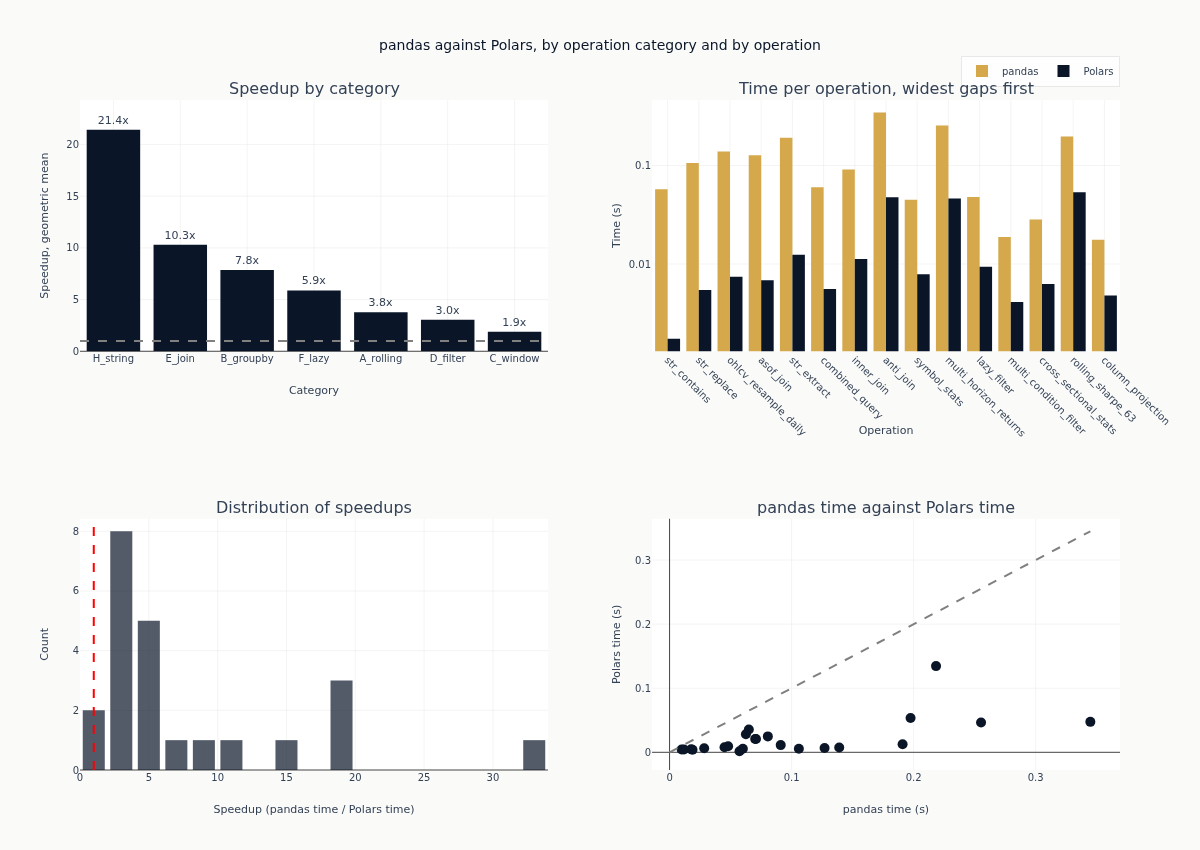

In [65]:
_charted_pandas_slower = int((sorted_results["pandas_time"] > sorted_results["polars_time"]).sum())
_charted = sorted_results.height
_below_diagonal = operations_faster
show_plotly_with_alt(
    fig,
    "Four panels. Top left, one bar per timed operation category giving the geometric "
    "mean speedup of Polars over pandas, tallest on the left, each labelled with its "
    "multiple, against a dashed line at parity. Top right, paired bars of pandas time "
    "and Polars time on a logarithmic seconds axis, for the operations with the widest "
    "gaps rather than for all of them; the pandas bar is the taller of the pair in "
    f"{_charted_pandas_slower} of the {_charted} pairs shown. Bottom left, a histogram "
    "of the speedups with a dashed line at parity. Bottom right, a scatter of pandas "
    "time against Polars time, one point per operation, with a dashed diagonal marking "
    f"equal times; {_below_diagonal} of the {results_df.height} points sit below the "
    "diagonal, one for each operation Polars finished sooner.",
)

## Save Results

In [66]:
# Save detailed results
csv_path = RESULTS_DIR / f"pandas_polars_{ACTIVE_SCALE.lower()}.csv"
results_df.write_csv(csv_path)
print(f"Results saved to: {display_path(csv_path)}")

# Save summary
summary_df = pl.DataFrame(
    {
        "metric": [
            "pandas_version",
            "polars_version",
            "scale",
            "total_rows",
            "geometric_mean_speedup",
            "operations_tested",
            "polars_faster_count",
            "pandas_faster_count",
            "cow_enabled",
            "pyarrow_strings",
        ],
        "value": [
            PANDAS_VERSION,
            POLARS_VERSION,
            ACTIVE_SCALE,
            str(total_rows),
            f"{overall_speedup:.2f}",
            str(results_df.height),
            str(operations_faster),
            str(operations_slower),
            str(COW_ENABLED),
            str(PYARROW_STRINGS),
        ],
    }
)
summary_path = RESULTS_DIR / f"pandas_polars_summary_{ACTIVE_SCALE.lower()}.csv"
summary_df.write_csv(summary_path)
print(f"Summary saved to: {display_path(summary_path)}")

Results saved to: 02_financial_data_universe/output/benchmark/pandas_polars_l.csv
Summary saved to: 02_financial_data_universe/output/benchmark/pandas_polars_summary_l.csv


## Key Takeaways

The ranking below is read off this run rather than written into the prose, because
it moves with the scale and with the machine.

In [67]:
_ranked = category_summary.sort("geometric_mean_speedup", descending=True)
_top2 = _ranked.head(2)["category"].to_list()
_bot2 = _ranked.tail(2)["category"].to_list()
print(f"Scale: {ACTIVE_SCALE} ({total_rows:,} rows)")
print(f"Widest Polars margin at this scale: {', '.join(_top2)}")
print(f"Narrowest margin, or pandas ahead: {', '.join(_bot2)}")

Scale: L (1,000,000 rows)
Widest Polars margin at this scale: H_string, E_join
Narrowest margin, or pandas ahead: D_filter, C_window


### What the table above shows

Each row is the geometric mean of the Polars-over-pandas speedups in that category,
at the scale this run used. The ordering depends on the scale, so the cell above
reads this run's widest and narrowest categories off the table rather than the prose
naming them.

What does not depend on the scale is the mechanism. Every Polars call pays a fixed
cost to plan and dispatch before any data is touched. On a small panel that cost is
a large share of a short operation, so the margin is narrow and unstable, and a
category can land on either side of parity between runs. As the panel grows, the
fixed cost stays where it is while the work grows, and the operations that
parallelize pull away. Run the notebook at two scales and the direction is visible;
which categories move most is a property of the machine's core count as much as of
the libraries.

### Decision framework

| Data size | Choice | Reason |
|-----------|--------|--------|
| < 100K rows | Either library | pandas stays competitive; Polars adds learning curve |
| 100K – 1M rows | Prefer Polars | Larger gap on join / groupby / string operations |
| > 1M rows | Polars | Parallelization advantage is largest here |
| Visualization | Convert to pandas | matplotlib / seaborn compatibility |

### Migration notes

1. **Upgrading pandas** to a version with Copy-on-Write and PyArrow-backed strings
   costs nothing at the call site and changes both the memory column and the string
   timings above. The setup cell says whether the pandas that ran had them.
2. **Moving to Polars** pays off first on the categories with the widest margin in
   the table above, at the scale you actually process.
3. **New projects**: start with Polars and convert to pandas at the plotting
   boundary, which is the one place the ecosystem still requires it.

**Book Reference**: Section 2.4 (*Storing Data*) discusses DataFrame engine
selection alongside on-disk format and database choices.

In [68]:
print("=" * 70)
print("BENCHMARK COMPLETE")
print("=" * 70)
print(f"pandas {PANDAS_VERSION} vs Polars {POLARS_VERSION}, scale {ACTIVE_SCALE}")
print(f"Results: {display_path(csv_path)}")

BENCHMARK COMPLETE
pandas 2.3.3 vs Polars 1.41.1, scale L
Results: 02_financial_data_universe/output/benchmark/pandas_polars_l.csv
